In [32]:
import pandas as pd

In [33]:
pwd()

'C:\\Users\\hyeonho\\Desktop\\Bjorn_Paulson\\research\\18_Circadian\\flim_pipeline\\notebooks'

In [34]:
df = pd.read_csv(r"..\results\fit_analysis_summary.csv")

In [35]:
df.head()

,filename,session_root,fixation_type,cell_type,em_filter_nm,acquisition_time,fit_set_key,n_components,n_px_total,n_px_final,pct_final,tau_mean_median_ps,tau_mean_mean_ps,tau_mean_std_ps,tau_mean_cv,amp_ratio_median,amp_ratio_mean,amp_ratio_std,amp_ratio_cv
0,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,20260501_KPC_fixed_dishes_on_SLIM,live,KPCWT,457,36:09.0,20260501_KPC_fixed_dishes_on_SLIM::batch2\fite...,2,65536,54888,83.8,848.039248,847.298658,54.402039,0.064206,3.377804,3.376719,0.423707,0.125479
1,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,20260501_KPC_fixed_dishes_on_SLIM,live,KPCWT,457,37:17.0,20260501_KPC_fixed_dishes_on_SLIM::batch2\fite...,2,65536,64781,98.8,870.983722,880.098029,67.167599,0.076318,3.243121,3.006660,0.760236,0.252851
2,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,20260501_KPC_fixed_dishes_on_SLIM,live,KPCWT,457,38:24.8,20260501_KPC_fixed_dishes_on_SLIM::batch2\fite...,2,65536,64618,98.6,891.573047,899.794616,72.810373,0.080919,2.919567,2.662900,0.887085,0.333127
3,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,20260501_KPC_fixed_dishes_on_SLIM,live,KPCWT,457,39:32.5,20260501_KPC_fixed_dishes_on_SLIM::batch2\fite...,2,65536,63998,97.7,907.551107,914.421723,83.613087,0.091438,2.027815,2.226370,0.807673,0.362776
4,13_KPC_live_posn1b_740nm_3040mW_u1_poc0p2_20x0...,20260501_KPC_fixed_dishes_on_SLIM,live,KPCWT,535,50:43.9,20260501_KPC_fixed_dishes_on_SLIM::batch2\fite...,2,65536,39161,59.8,653.464739,655.350596,64.162736,0.097906,3.521855,3.544793,0.510351,0.143972


In [36]:
#df['fix_time']=
df['date'] =  pd.to_datetime(df.session_root.str.split('_').str[0], format='%Y%m%d')

In [37]:
df['fix_time']=[int(k.lower().split('form')[1][:2]) if k.lower().find('form')>-1 else 0 for k in df.filename.values ]

In [38]:
df.columns

Index(['filename', 'session_root', 'fixation_type', 'cell_type',
       'em_filter_nm', 'acquisition_time', 'fit_set_key', 'n_components',
       'n_px_total', 'n_px_final', 'pct_final', 'tau_mean_median_ps',
       'tau_mean_mean_ps', 'tau_mean_std_ps', 'tau_mean_cv',
       'amp_ratio_median', 'amp_ratio_mean', 'amp_ratio_std', 'amp_ratio_cv',
       'date', 'fix_time'],
      dtype='str')

In [39]:
df['poc'] = df.filename.str.split('_poc').str[1].str.split('_').str[0]
df['pockelcell'] = df.poc.str.replace('p','.').astype(float)

In [40]:
df['PC'] = ['High' if k>0.3 else 'Low' for k in df.pockelcell.values]
df.PC.value_counts()

PC
Low     251
High    197
Name: count, dtype: int64

# data describe

In [43]:
df.groupby(['fixation_type', 'em_filter_nm', 'date','cell_type','fix_time', 'PC']).size()

fixation_type  em_filter_nm  date        cell_type  fix_time  PC  
form           457           2026-05-09  BKO        20        High    16
                                                              Low     16
                                         KPCWT      20        High    23
                                                              Low     12
                             2026-05-20  BKO        10        High    17
                                                              Low     17
                                         KPCWT      10        High    16
                                                              Low     17
               535           2026-05-09  BKO        20        High    16
                                                              Low     16
                                         KPCWT      20        Low     12
                             2026-05-20  BKO        10        High    17
                                                         

In [12]:
df.session_root.unique(), df.cell_type.unique()

(<StringArray>
 ['20260501_KPC_fixed_dishes_on_SLIM',         '20260508_KPC_live_on_SLIM',
  '20260509_KPC_fixed_dishes_on_SLIM',         '20260517_KPC_live_on_SLIM',
     '20260520_KPC_fixed_dishes_SLIM',            '20260521_KPC_live_SLIM']
 Length: 6, dtype: str,
 <StringArray>
 ['KPCWT', 'BKO']
 Length: 2, dtype: str)

In [15]:
import seaborn as sns

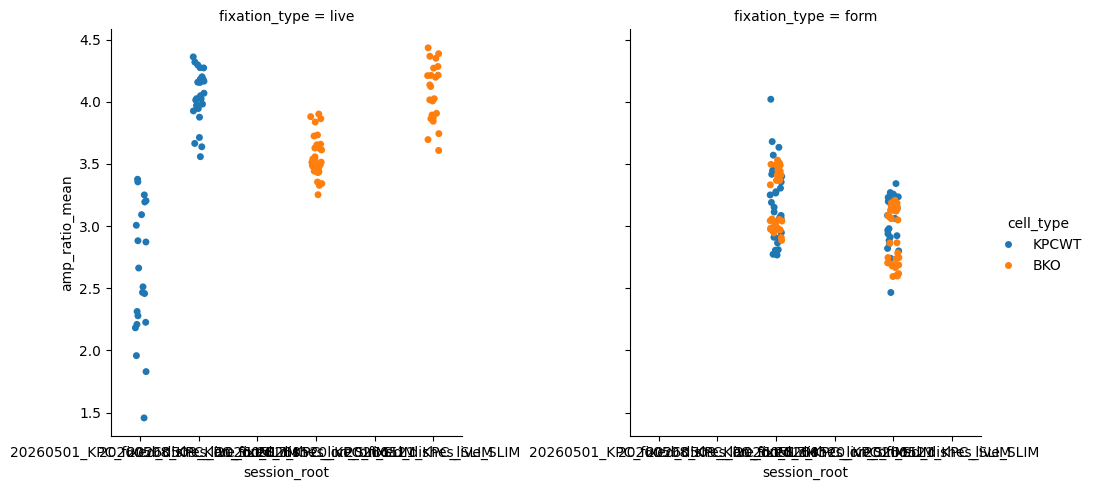

In [26]:
sns.catplot(x='session_root',y='amp_ratio_mean', data=df.loc[(df.em_filter_nm==457)], hue='cell_type',col='fixation_type')

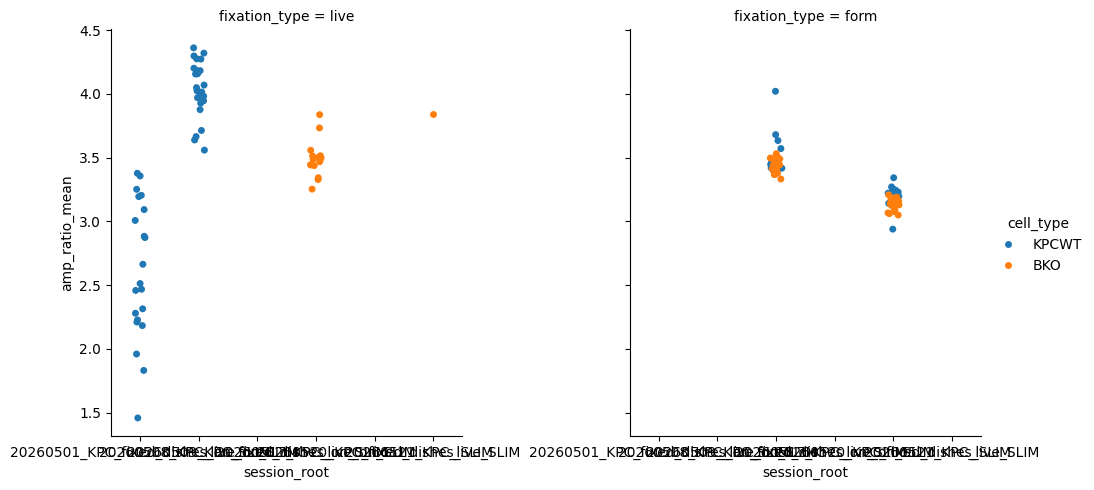

In [25]:
sns.catplot(x='session_root',y='amp_ratio_mean', data=df.loc[(df.em_filter_nm==457) & (df.PC == "Low") ], hue='cell_type',col='fixation_type')

In [19]:
df.loc[df.em_filter_nm==457].shape

(236, 19)

## a1/a2 median

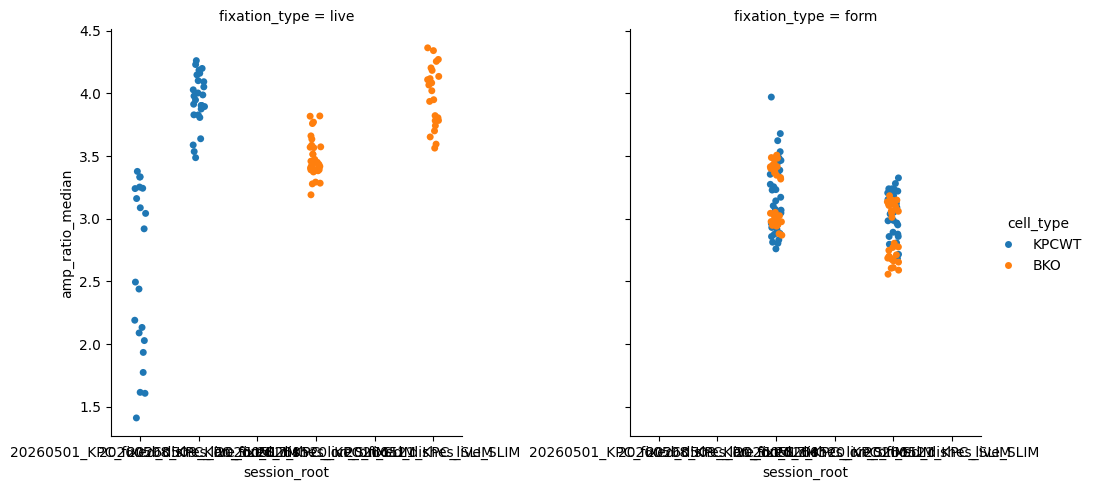

In [14]:
sns.catplot(x='session_root',y='amp_ratio_median', data=df.loc[df.em_filter_nm==457], hue='cell_type',col='fixation_type')

In [35]:
df.columns

Index(['filename', 'session_root', 'fixation_type', 'cell_type',
       'em_filter_nm', 'acquisition_time', 'fit_set_key', 'n_components',
       'n_px_total', 'n_px_final', 'pct_final', 'tau_mean_median_ps',
       'tau_mean_mean_ps', 'tau_mean_std_ps', 'tau_mean_cv',
       'amp_ratio_median', 'amp_ratio_mean', 'amp_ratio_std', 'amp_ratio_cv',
       'fix_time', 'date'],
      dtype='str')

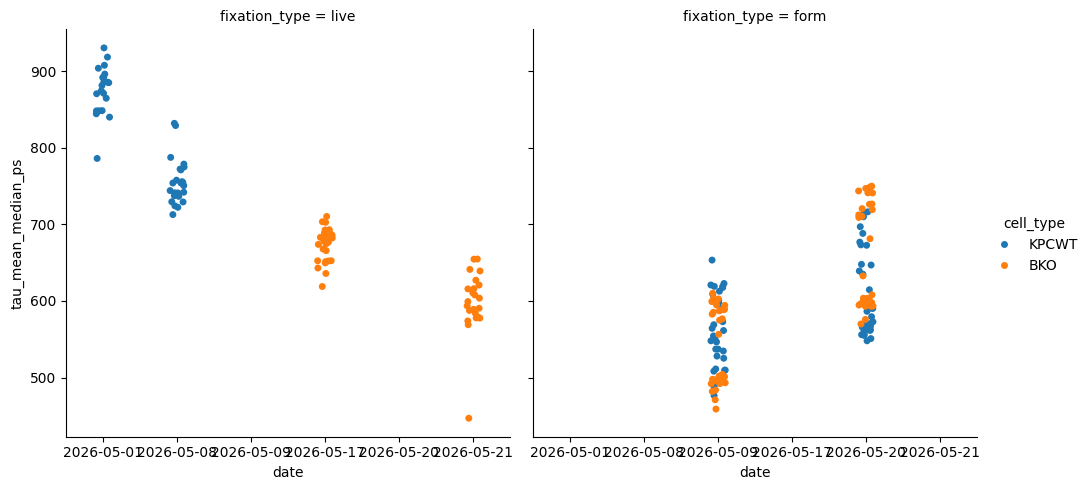

In [36]:
sns.catplot(x='date',y='tau_mean_median_ps', data=df.loc[df.em_filter_nm==457], hue='cell_type',col='fixation_type')

## taumean

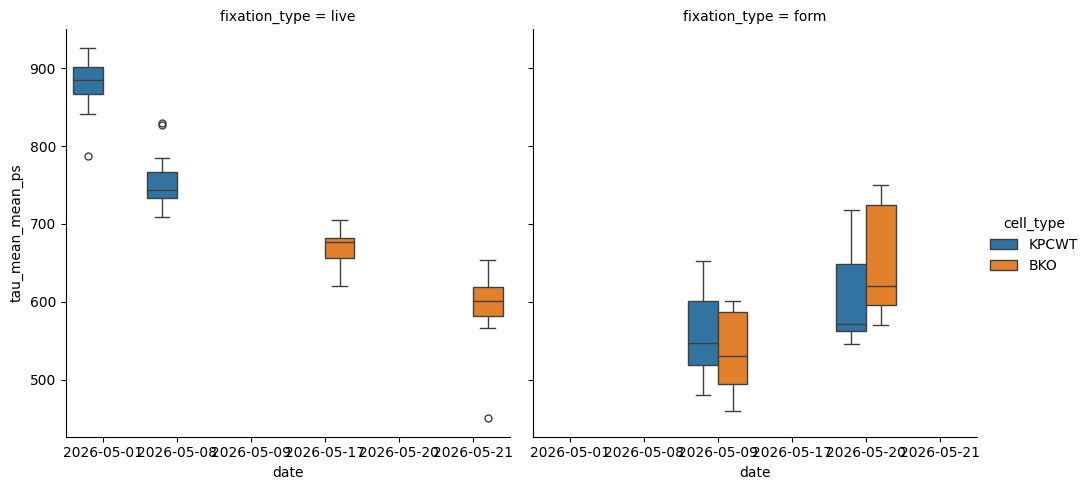

In [43]:
sns.catplot(x='date',y='tau_mean_mean_ps', data=df.loc[df.em_filter_nm==457], hue='cell_type',col='fixation_type',kind='box')

## two pockel cell data filter

poc
0p25    150
0p6     147
0p2     100
0p45     32
0p5      18
0p1       1
Name: count, dtype: int64

PC
Low     251
High    197
Name: count, dtype: int64

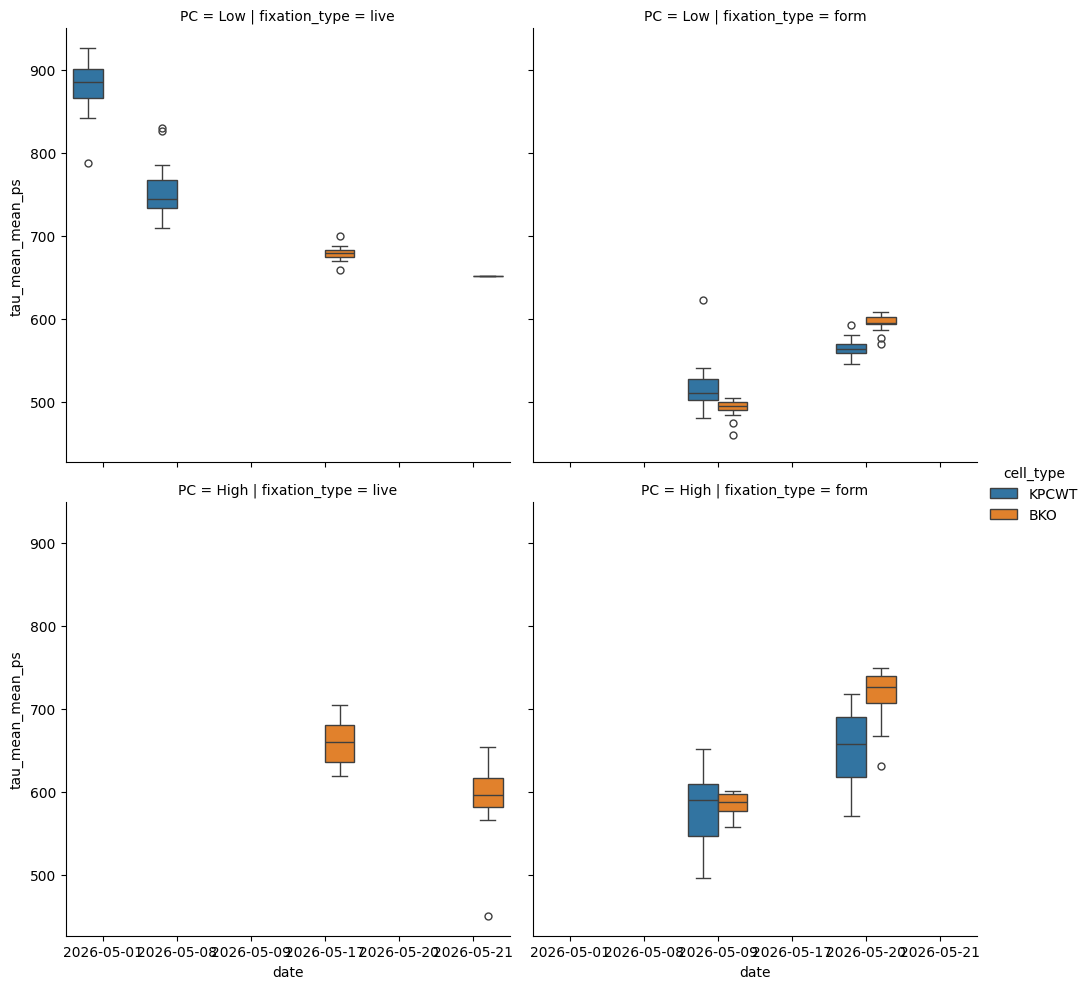

In [169]:
sns.catplot(x='date',y='tau_mean_mean_ps', data=df.loc[df.em_filter_nm==457], hue='cell_type',col='fixation_type',kind='box',row='PC')

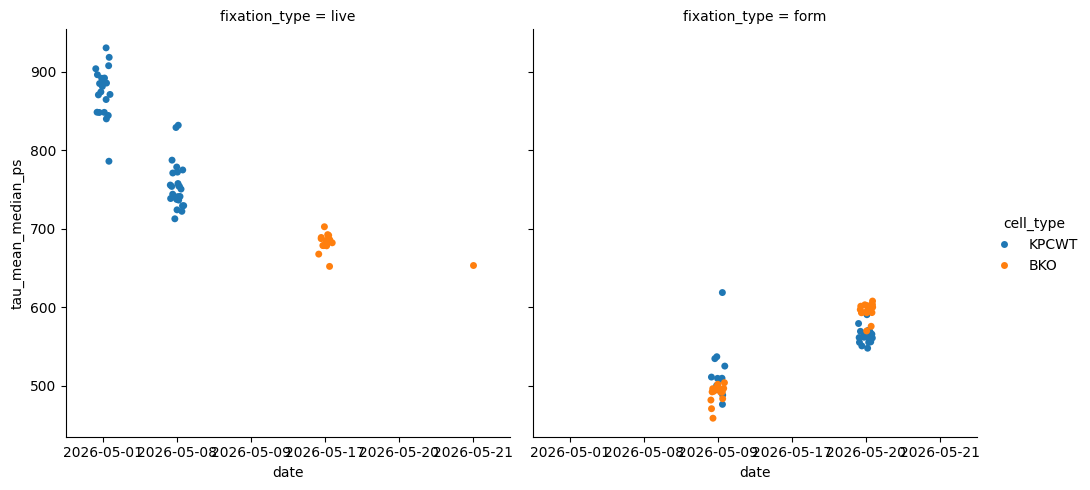

In [171]:
sns.catplot(x='date',y='tau_mean_median_ps', data=df.loc[(df.em_filter_nm==457)&(df.PC=='Low')], hue='cell_type',col='fixation_type')

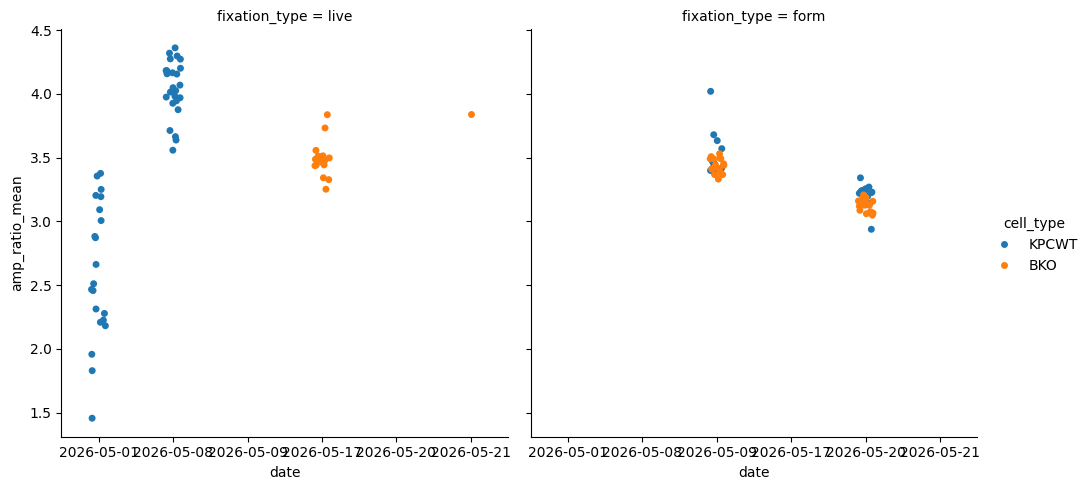

In [45]:
sns.catplot(x='date',y='amp_ratio_mean', data=df.loc[(df.em_filter_nm==457)&(df.PC=='Low')], hue='cell_type',col='fixation_type')

# reading asc

In [45]:
filenames = df.loc[df.em_filter_nm==457]['filename'].unique()
len(filenames)

236

In [52]:
%%time
from pathlib import Path
sdtfiles = list(Path(r"E:\18_RK_Circadian\data\raw").rglob('*.sdt'))
len(sdtfiles)

CPU times: total: 1.3 s
Wall time: 1.31 s


722

In [ ]:
for filename in filenames:
    #print(filename)
    corr_file_path = [k for k in sdtfiles if k.name == filename]
    
    assert len(corr_file_path)==1, f"Expected exactly one match for {filename}, found {len(corr_file_path)}"

'4_BKOCO2live_740nm_3085mW_u1_poc0p5_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0009'

In [ ]:
fn = Path(filename)
[k for k in list(corr_file_path[0].parent.rglob('*.asc')) if (k.name.startswith(fn.stem))&(k.name.endswith('photons.asc'))]

[WindowsPath('E:/18_RK_Circadian/data/raw/20260521_KPC_live_SLIM/fitet-sf-c2-b1/4_BKOCO2live_740nm_3085mW_u1_poc0p5_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0009_photons.asc'),
 WindowsPath('E:/18_RK_Circadian/data/raw/20260521_KPC_live_SLIM/fitet-sf-c2-b3/4_BKOCO2live_740nm_3085mW_u1_poc0p5_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0009_photons.asc'),
 WindowsPath('E:/18_RK_Circadian/data/raw/20260521_KPC_live_SLIM/fitet-sf-c2-b9/4_BKOCO2live_740nm_3085mW_u1_poc0p5_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0009_photons.asc'),
 WindowsPath('E:/18_RK_Circadian/data/raw/20260521_KPC_live_SLIM/fitet-sz-c2-b1/4_BKOCO2live_740nm_3085mW_u1_poc0p5_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0009_photons.asc'),
 WindowsPath('E:/18_RK_Circadian/data/raw/20260521_KPC_live_SLIM/fitet-sz-c2-b3/4_BKOCO2live_740nm_3085mW_u1_poc0p5_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0009_photons.asc'),
 WindowsPath('E:/18_RK_Circadian/data/raw/20260521_KPC_live_SLIM/fitet-sz-c2-b9/4_BKOCO2li

In [70]:
import numpy as np

In [74]:
for filename in filenames:
    #print(filename)
    corr_file_path = [k for k in sdtfiles if k.name == filename]
    assert len(corr_file_path)==1, f"Expected exactly one match for {filename}, found {len(corr_file_path)}"
    fn = Path(filename)
    asc_ph_files = [k for k in list(corr_file_path[0].parent.rglob('*.asc')) if (k.name.startswith(fn.stem))&(k.name.endswith('photons.asc'))]
    szfiles = [k for k in asc_ph_files if k.parts[-2].find('-sz-')>-1]
    for szfile in szfiles:
        shiftfile = str(szfile).replace('photons.asc','shift.asc') 
        shift_data = np.loadtxt(shiftfile)
        if shift_data.sum()>0:
            print(szfile.name,  shift_data.sum())
        #break
    #break

### SPC IMAGE 8.9.85 keeps the shift to zero on MLE if you set the checkbox as fixed

In [75]:
fn_dict={}
for filename in filenames:
    #print(filename)
    corr_file_path = [k for k in sdtfiles if k.name == filename]
    assert len(corr_file_path)==1, f"Expected exactly one match for {filename}, found {len(corr_file_path)}"
    fn = Path(filename)
    asc_ph_files = [k for k in list(corr_file_path[0].parent.rglob('*.asc')) if (k.name.startswith(fn.stem))&(k.name.endswith('photons.asc'))]
    szfiles = [k for k in asc_ph_files if k.parts[-2].find('fitet-sz-c2')>-1]
    fn_dict[filename]=szfiles[-1]

In [79]:
fn_dict[filename].name

'4_BKOCO2live_740nm_3085mW_u1_poc0p5_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0009_photons.asc'

In [82]:
from matplotlib.pyplot import *

In [85]:
from skimage.filters import threshold_local

In [192]:
data_dict = {}
for filename in fn_dict:
    #print(filename, fn_dict[filename].parent)
    ph_file = np.loadtxt(fn_dict[filename])
    color_coded_file = Path(str(fn_dict[filename]).replace('photons.asc','color coded value.asc'))
    if color_coded_file.exists():
        taumean_file = np.loadtxt(color_coded_file)
    else:
        taumean_file = np.array([np.nan])
    a1_file = Path(str(fn_dict[filename]).replace('photons.asc','a1.asc')) 
    if a1_file.exists():
        a1_file = np.loadtxt(a1_file)
    else:
        a1_file = np.array([np.nan])
    a2_file = Path(str(fn_dict[filename]).replace('photons.asc', 'a2.asc'))
    if a2_file.exists():
        a2_file = np.loadtxt(a2_file)
    else:
        a2_file = np.array([np.nan])
    #a1a2 = a1_file/a2_file
    chi_file = Path(str(fn_dict[filename]).replace('photons.asc', 'chi.asc'))
    if chi_file.exists():
        chi_file = np.loadtxt(chi_file)
    else:
        chi_file = np.array([np.nan])
    ma = ph_file > ph_file.mean()*1.2
    #mask = threshold_local(ph_file, block_size=11, offset=8)
    #imshow(ma)
    data_dict[filename] = {
        'filepath':fn_dict[filename],
        'ph':ph_file[ma].mean(), 
        'taumean':taumean_file[ma].mean(),
        'a1':a1_file[ma].mean(),
        'a2':a2_file[ma].mean(),
        'chi':chi_file[ma].mean()}
    
    make_fig()
    output = Path(r'E:\18_RK_Circadian\data\processed_temp\preview') / (fn_dict[filename].stem + '_preview.png')
    savefig(output)
    close()
    
    #break

In [178]:
#ph_file[ma].mean(), ph_file[~ma].mean(), a1_file[ma].mean(), a1_file[~ma].mean()

In [189]:
def make_fig():
    figure(figsize=(25,3))
    subplot(1,6,1)
    imshow(ph_file)
    title(f'{ph_file[ma].mean():.1f} vs {ph_file[~ma].mean():.1f}')
    colorbar()
    subplot(1,6,2) 
    imshow(taumean_file)
    title(f'{taumean_file[ma].mean():.1f} vs {taumean_file[~ma].mean():.1f}')
    colorbar()
    subplot(1,6 ,3)  
    imshow(a1_file)
    title(f'{a1_file[ma].mean():.1f} vs {a1_file[~ma].mean():.1f}')
    colorbar()
    subplot(1,6,4)  
    imshow(a2_file)
    title(f'{a2_file[ma].mean():.1f} vs {a2_file[~ma].mean():.1f}')
    colorbar()
    subplot(1,6,5)
    imshow(chi_file)
    title(f'{chi_file[ma].mean():.1f} vs {chi_file[~ma].mean():.1f}')
    colorbar()
    subplot(1,6,6)
    imshow(ma)
    title(f'Mask: {ma.sum()} pixels')
    colorbar()



In [137]:
df1 = pd.DataFrame.from_dict(data_dict, orient='index')

In [138]:
df1.reset_index(inplace=True)

In [139]:
df1.columns

Index(['index', 'filepath', 'ph', 'taumean', 'a1', 'a2', 'chi'], dtype='str')

In [140]:
df1.columns = ['filename', 'filepath', 'ph_mean', 'taumean_mean', 'a1_mean', 'a2_mean', 'chi_mean']

In [141]:
df1.head()

,filename,filepath,ph_mean,taumean_mean,a1_mean,a2_mean,chi_mean
0,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,E:\18_RK_Circadian\data\raw\20260501_KPC_fixed...,35.463428,852.359470,852.359470,144.540217,1.066105
1,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,E:\18_RK_Circadian\data\raw\20260501_KPC_fixed...,75.229113,867.640295,867.640295,334.106799,1.141981
2,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,E:\18_RK_Circadian\data\raw\20260501_KPC_fixed...,70.385889,875.820037,875.820037,304.176009,1.151340
3,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,E:\18_RK_Circadian\data\raw\20260501_KPC_fixed...,56.971252,884.776969,884.776969,259.326277,1.193645
4,14_KPC_live_posn2_740nm_3040mW_u1_poc0p2_20x0p...,E:\18_RK_Circadian\data\raw\20260501_KPC_fixed...,15.217382,840.851958,840.851958,67.078416,1.040288


In [154]:
df1['datex'] = [k.parts[4].split('_')[0] for k in df1.filepath.values]
df1.datex.value_counts()

datex
20260509    67
20260520    67
20260517    32
20260508    26
20260521    23
20260501    21
Name: count, dtype: int64

In [ ]:
df1['fixation'] = ['L' if k.lower().find('live')>-1 else 'F' for k in df1.filename.values] 
df1.fixation.value_counts()

In [147]:
df1['fixation'] = ['L' if k.lower().find('live')>-1 else 'F' for k in df1.filename.values] 
df1.fixation.value_counts()

fixation
F    134
L    102
Name: count, dtype: int64

In [144]:
df1['celltype'] = [k.split('_')[1][0] for k in df1.filename.values] 
df1.celltype.value_counts()

celltype
B    121
K    115
Name: count, dtype: int64

In [156]:
df1.head()

,filename,filepath,ph_mean,taumean_mean,a1_mean,a2_mean,chi_mean,celltype,fixation,datex
0,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,E:\18_RK_Circadian\data\raw\20260501_KPC_fixed...,35.463428,852.359470,852.359470,144.540217,1.066105,K,L,20260501
1,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,E:\18_RK_Circadian\data\raw\20260501_KPC_fixed...,75.229113,867.640295,867.640295,334.106799,1.141981,K,L,20260501
2,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,E:\18_RK_Circadian\data\raw\20260501_KPC_fixed...,70.385889,875.820037,875.820037,304.176009,1.151340,K,L,20260501
3,13_KPC_live_posn1_740nm_3040mW_u1_poc0p2_20x0p...,E:\18_RK_Circadian\data\raw\20260501_KPC_fixed...,56.971252,884.776969,884.776969,259.326277,1.193645,K,L,20260501
4,14_KPC_live_posn2_740nm_3040mW_u1_poc0p2_20x0p...,E:\18_RK_Circadian\data\raw\20260501_KPC_fixed...,15.217382,840.851958,840.851958,67.078416,1.040288,K,L,20260501


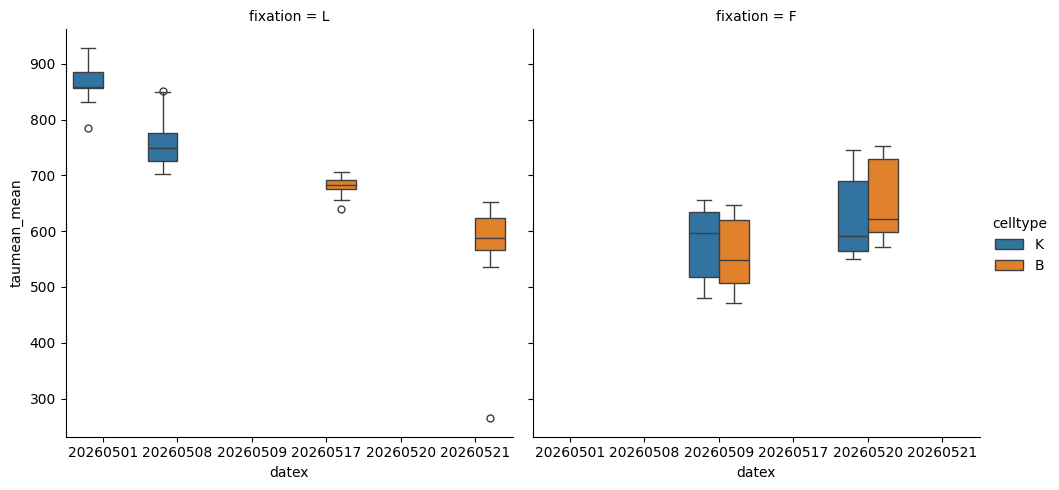

In [158]:
sns.catplot(x='datex',y='taumean_mean', data=df1, hue='celltype',col='fixation',kind='box')

In [159]:
df1['a1bya2'] = df1.a1_mean/df1.a2_mean

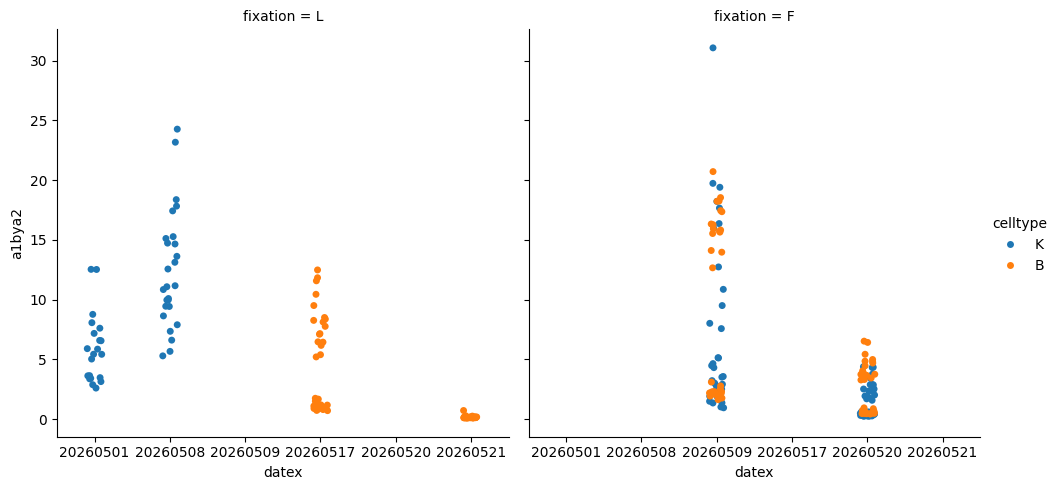

In [161]:
sns.catplot(x='datex',y='a1bya2', data=df1, hue='celltype',col='fixation',kind='strip')

In [44]:
## 8-cell fits

In [ ]:
Cells